In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve, make_scorer)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
df_original = pd.read_csv('ml-dataset-50-50-idle-timeout-2-17-10-2025-multiple-attacks.csv')
df_corrected = pd.read_csv('ml-dataset-50-50-idle-timeout-2-17-10-2025-multiple-attacks-corrected.csv')

print(f"\nOriginal Dataset shape: {df_original.shape}")
print(f"Corrected Dataset shape: {df_corrected.shape}")


Original Dataset shape: (3354, 72)
Corrected Dataset shape: (3354, 72)


In [47]:
print("DATASET STATISTICS COMPARISON")

print("\nORIGINAL DATASET:")
print(f"  Total samples: {len(df_original)}")
print(f"  Normal samples: {(df_original['attack'] == 0).sum()} ({(df_original['attack'] == 0).sum() / len(df_original) * 100:.2f}%)")
print(f"  Attack samples: {df_original['attack'].sum()} ({df_original['attack'].sum() / len(df_original) * 100:.2f}%)")
print(f"    - SYN attacks: {df_original['attack_syn'].sum()}")
print(f"    - UDP attacks: {df_original['attack_udp'].sum()}")
print(f"    - ICMP attacks: {df_original['attack_icmp'].sum()}")

print("\nCORRECTED DATASET:")
print(f"  Total samples: {len(df_corrected)}")
print(f"  Normal samples: {(df_corrected['attack'] == 0).sum()} ({(df_corrected['attack'] == 0).sum() / len(df_corrected) * 100:.2f}%)")
print(f"  Attack samples: {df_corrected['attack'].sum()} ({df_corrected['attack'].sum() / len(df_corrected) * 100:.2f}%)")
print(f"    - SYN attacks: {df_corrected['attack_syn'].sum()}")
print(f"    - UDP attacks: {df_corrected['attack_udp'].sum()}")
print(f"    - ICMP attacks: {df_corrected['attack_icmp'].sum()}")

print("\nIMPROVEMENT:")
print(f"  Additional attack samples: {df_corrected['attack'].sum() - df_original['attack'].sum()}")
print(f"    - Additional SYN: {df_corrected['attack_syn'].sum() - df_original['attack_syn'].sum()}")
print(f"    - Additional UDP: {df_corrected['attack_udp'].sum() - df_original['attack_udp'].sum()}")
print(f"    - Additional ICMP: {df_corrected['attack_icmp'].sum() - df_original['attack_icmp'].sum()}")

DATASET STATISTICS COMPARISON

ORIGINAL DATASET:
  Total samples: 3354
  Normal samples: 1777 (52.98%)
  Attack samples: 1577 (47.02%)
    - SYN attacks: 634
    - UDP attacks: 599
    - ICMP attacks: 344

CORRECTED DATASET:
  Total samples: 3354
  Normal samples: 1583 (47.20%)
  Attack samples: 1771 (52.80%)
    - SYN attacks: 734
    - UDP attacks: 651
    - ICMP attacks: 386

IMPROVEMENT:
  Additional attack samples: 194
    - Additional SYN: 100
    - Additional UDP: 52
    - Additional ICMP: 42


In [48]:
def prepare_data(df, task='binary'):
    """
    Prepare data for training.
    
    Args:
        df: DataFrame with features and labels
        task: 'binary' for attack vs normal, 'multiclass' for attack type classification
    
    Returns:
        X, y split into train and test sets
    """
    # Features (excluding timestamp and all attack labels)
    feature_cols = [col for col in df.columns if col not in ['timestamp', 'attack', 'attack_syn', 'attack_udp', 'attack_icmp']]
    X = df[feature_cols]
    
    if task == 'binary':
        y = df['attack']
    elif task == 'multiclass':
        # normal (0), syn (1), udp (2), icmp (3)
        y = np.zeros(len(df), dtype=int)
        y[df['attack_syn'] == 1] = 1
        y[df['attack_udp'] == 1] = 2
        y[df['attack_icmp'] == 1] = 3
    
    return X, y

In [49]:
def train_and_evaluate_binary(X_train, X_test, y_train, y_test, dataset_name, 
                                          search_method='grid'):
    """
    Train and evaluate binary classifier with hyperparameter tuning.
    
    Args:
        search_method: 'grid' for GridSearchCV, 'random' for RandomizedSearchCV
    """
    print(f"\n{'='*80}")
    print(f"BINARY CLASSIFICATION WITH HYPERPARAMETER TUNING - {dataset_name}")
    print(f"{'='*80}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define hyperparameter grid
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization strength
        'penalty': ['l1', 'l2'],                      # Regularization type
        'solver': ['liblinear', 'saga'],              # Compatible solvers for l1/l2
        'class_weight': ['balanced', None],           # Class weighting
        'max_iter': [1000, 2000]                      # Convergence iterations
    }
    
    # Alternative: RandomizedSearchCV parameter distributions
    param_distributions = {
        'C': np.logspace(-3, 2, 20),                  # 20 values between 0.001 and 100
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': ['balanced', None],
        'max_iter': [1000, 2000, 3000]
    }
    
    # Base model
    lr_base = LogisticRegression(random_state=42, n_jobs=-1)
    
    if search_method == 'grid':
        print("\nUsing GridSearchCV (exhaustive search)...")
        search = GridSearchCV(
            estimator=lr_base,
            param_grid=param_grid,
            cv=5,                              # 5-fold cross-validation
            scoring='f1',                      # Optimize for F1-score (good for imbalanced data)
            n_jobs=-1,                         # Use all CPU cores
            verbose=1,
            refit=True                         # Refit on entire training set with best params
        )
    else:
        print("\nUsing RandomizedSearchCV (random sampling)...")
        search = RandomizedSearchCV(
            estimator=lr_base,
            param_distributions=param_distributions,
            n_iter=50,                         # Number of parameter combinations to try
            cv=5,
            scoring='f1',
            n_jobs=-1,
            verbose=1,
            random_state=42,
            refit=True
        )
    
    print("Searching for best hyperparameters...")
    search.fit(X_train_scaled, y_train)
    
    # Best model
    best_model = search.best_estimator_
    
    print(f"\n{'BEST HYPERPARAMETERS':^40}")
    print("-" * 40)
    for param, value in search.best_params_.items():
        print(f"{param:15s}: {value}")
    print(f"\nBest CV Score (F1): {search.best_score_:.4f}")
    
    # Predictions with best model
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"\n{'TEST SET RESULTS':^40}")
    print("-" * 40)
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{'CONFUSION MATRIX':^40}")
    print("-" * 40)
    print(f"True Negatives:  {cm[0,0]:>6}")
    print(f"False Positives: {cm[0,1]:>6}")
    print(f"False Negatives: {cm[1,0]:>6}")
    print(f"True Positives:  {cm[1,1]:>6}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': np.abs(best_model.coef_[0])
    }).sort_values('coefficient', ascending=False)
    
    # Additional: Show top 5 hyperparameter combinations
    print(f"\n{'TOP 5 HYPERPARAMETER COMBINATIONS':^80}")
    print("-" * 80)
    cv_results = pd.DataFrame(search.cv_results_)
    top_5 = cv_results.nlargest(5, 'mean_test_score')[
        ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    ]
    for idx, row in top_5.iterrows():
        print(f"\nRank {row['rank_test_score']}: F1={row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
        print(f"  Params: {row['params']}")
    
    return {
        'model': best_model,
        'scaler': scaler,
        'metrics': metrics,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'feature_importance': feature_importance,
        'best_params': search.best_params_,
        'cv_results': cv_results
    }

In [50]:
def train_and_evaluate_multiclass(X_train, X_test, y_train, y_test, 
                                              dataset_name, search_method='grid'):
    """
    Train and evaluate multi-class classifier with hyperparameter tuning.
    """
    print(f"\n{'='*80}")
    print(f"MULTI-CLASS CLASSIFICATION WITH TUNING - {dataset_name}")
    print(f"{'='*80}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define hyperparameter grid for multi-class
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'penalty': ['l2'],                           # l1 not supported with multinomial
        'solver': ['lbfgs', 'saga'],                 
        'multi_class': ['multinomial', 'ovr'],       # Multinomial vs One-vs-Rest
        'class_weight': ['balanced', None],
        'max_iter': [1000, 2000]
    }
    
    param_distributions = {
        'C': np.logspace(-2, 2, 20),
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'multi_class': ['multinomial', 'ovr'],
        'class_weight': ['balanced', None],
        'max_iter': [1000, 2000, 3000]
    }
    
    # Base model
    lr_base = LogisticRegression(random_state=42, n_jobs=-1)
    
    if search_method == 'grid':
        search = GridSearchCV(
            estimator=lr_base,
            param_grid=param_grid,
            cv=5,
            scoring='f1_weighted',                   # Weighted F1 for multi-class
            n_jobs=-1,
            verbose=1,
            refit=True
        )
    else:
        search = RandomizedSearchCV(
            estimator=lr_base,
            param_distributions=param_distributions,
            n_iter=40,
            cv=5,
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=1,
            random_state=42,
            refit=True
        )
    
    print("Searching for best hyperparameters...")
    search.fit(X_train_scaled, y_train)
    
    best_model = search.best_estimator_
    
    print(f"\n{'BEST HYPERPARAMETERS':^40}")
    print("-" * 40)
    for param, value in search.best_params_.items():
        print(f"{param:15s}: {value}")
    print(f"\nBest CV Score (F1-weighted): {search.best_score_:.4f}")
    
    # Predictions
    y_pred = best_model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    class_names = ['Normal', 'SYN', 'UDP', 'ICMP']
    
    print(f"\n{'TEST SET RESULTS':^60}")
    print("-" * 60)
    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"\n{'Classification Report':^60}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': np.mean(np.abs(best_model.coef_), axis=0)
    }).sort_values('coefficient', ascending=False)
    
    return {
        'model': best_model,
        'scaler': scaler,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred,
        'feature_importance': feature_importance,
        'class_names': class_names,
        'best_params': search.best_params_,
        'cv_results': pd.DataFrame(search.cv_results_)
    }

In [51]:
# Binary classification data
X_orig_bin, y_orig_bin = prepare_data(df_original, task='binary')
X_corr_bin, y_corr_bin = prepare_data(df_corrected, task='binary')

# Multi-class classification data
X_orig_multi, y_orig_multi = prepare_data(df_original, task='multiclass')
X_corr_multi, y_corr_multi = prepare_data(df_corrected, task='multiclass')

# Split data
X_train_orig_bin, X_test_orig_bin, y_train_orig_bin, y_test_orig_bin = train_test_split(
    X_orig_bin, y_orig_bin, test_size=0.2, random_state=42, stratify=y_orig_bin
)

X_train_corr_bin, X_test_corr_bin, y_train_corr_bin, y_test_corr_bin = train_test_split(
    X_corr_bin, y_corr_bin, test_size=0.2, random_state=42, stratify=y_corr_bin
)

X_train_orig_multi, X_test_orig_multi, y_train_orig_multi, y_test_orig_multi = train_test_split(
    X_orig_multi, y_orig_multi, test_size=0.2, random_state=42, stratify=y_orig_multi
)

X_train_corr_multi, X_test_corr_multi, y_train_corr_multi, y_test_corr_multi = train_test_split(
    X_corr_multi, y_corr_multi, test_size=0.2, random_state=42, stratify=y_corr_multi
)

print(f"Number of features: {X_orig_bin.shape[1]}")

Number of features: 67


In [52]:
# Train and evaluate binary classification
print("BINARY CLASSIFICATION (ATTACK vs NORMAL)")

results_orig_bin = train_and_evaluate_binary(
    X_train_orig_bin, X_test_orig_bin, y_train_orig_bin, y_test_orig_bin,
    "ORIGINAL DATASET"
)

results_corr_bin = train_and_evaluate_binary(
    X_train_corr_bin, X_test_corr_bin, y_train_corr_bin, y_test_corr_bin,
    "CORRECTED DATASET"
)

BINARY CLASSIFICATION (ATTACK vs NORMAL)

BINARY CLASSIFICATION WITH HYPERPARAMETER TUNING - ORIGINAL DATASET

Using GridSearchCV (exhaustive search)...
Searching for best hyperparameters...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

          BEST HYPERPARAMETERS          
----------------------------------------
C              : 100.0
class_weight   : balanced
max_iter       : 1000
penalty        : l1
solver         : liblinear

Best CV Score (F1): 0.8697

            TEST SET RESULTS            
----------------------------------------
Accuracy:  0.8718
Precision: 0.8418
Recall:    0.8952
F1-Score:  0.8677
ROC-AUC:   0.9223

            CONFUSION MATRIX            
----------------------------------------
True Negatives:     303
False Positives:     53
False Negatives:     33
True Positives:     282

                       TOP 5 HYPERPARAMETER COMBINATIONS                        
--------------------------------------------------------------------------------

Ra

In [53]:
# Train and evaluate multi-class classification
print("MULTI-CLASS CLASSIFICATION (NORMAL, SYN, UDP, ICMP)")

results_orig_multi = train_and_evaluate_multiclass(
    X_train_orig_multi, X_test_orig_multi, y_train_orig_multi, y_test_orig_multi,
    "ORIGINAL DATASET"
)

results_corr_multi = train_and_evaluate_multiclass(
    X_train_corr_multi, X_test_corr_multi, y_train_corr_multi, y_test_corr_multi,
    "CORRECTED DATASET"
)

MULTI-CLASS CLASSIFICATION (NORMAL, SYN, UDP, ICMP)

MULTI-CLASS CLASSIFICATION WITH TUNING - ORIGINAL DATASET
Searching for best hyperparameters...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

          BEST HYPERPARAMETERS          
----------------------------------------
C              : 100.0
class_weight   : balanced
max_iter       : 1000
multi_class    : multinomial
penalty        : l2
solver         : lbfgs

Best CV Score (F1-weighted): 0.8673

                      TEST SET RESULTS                      
------------------------------------------------------------
Overall Accuracy: 0.8584

                   Classification Report                    
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.94      0.83      0.88       355
         SYN       0.72      0.85      0.78       127
         UDP       0.85      0.97      0.91       120
        ICMP       0.80      0.83     

In [54]:
print("COMPARISON SUMMARY")

print("\nBINARY CLASSIFICATION IMPROVEMENT")

metrics_comparison_bin = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Original': [
        results_orig_bin['metrics']['accuracy'],
        results_orig_bin['metrics']['precision'],
        results_orig_bin['metrics']['recall'],
        results_orig_bin['metrics']['f1'],
        results_orig_bin['metrics']['roc_auc']
    ],
    'Corrected': [
        results_corr_bin['metrics']['accuracy'],
        results_corr_bin['metrics']['precision'],
        results_corr_bin['metrics']['recall'],
        results_corr_bin['metrics']['f1'],
        results_corr_bin['metrics']['roc_auc']
    ]
})

metrics_comparison_bin['Improvement'] = metrics_comparison_bin['Corrected'] - metrics_comparison_bin['Original']
metrics_comparison_bin['Improvement %'] = (metrics_comparison_bin['Improvement'] / metrics_comparison_bin['Original']) * 100

print(metrics_comparison_bin.to_string(index=False))

print("\n\nMULTI-CLASS CLASSIFICATION IMPROVEMENT")

accuracy_improvement = results_corr_multi['accuracy'] - results_orig_multi['accuracy']
accuracy_improvement_pct = (accuracy_improvement / results_orig_multi['accuracy']) * 100

print(f"Original Accuracy:  {results_orig_multi['accuracy']:.4f}")
print(f"Corrected Accuracy: {results_corr_multi['accuracy']:.4f}")
print(f"Improvement:        {accuracy_improvement:+.4f} ({accuracy_improvement_pct:+.2f}%)")

COMPARISON SUMMARY

BINARY CLASSIFICATION IMPROVEMENT
   Metric  Original  Corrected  Improvement  Improvement %
 Accuracy  0.871833   0.919523     0.047690       5.470085
Precision  0.841791   0.933526     0.091735      10.897594
   Recall  0.895238   0.912429     0.017191       1.920303
 F1-Score  0.867692   0.922857     0.055165       6.357649
  ROC-AUC  0.922258   0.960283     0.038025       4.123009


MULTI-CLASS CLASSIFICATION IMPROVEMENT
Original Accuracy:  0.8584
Corrected Accuracy: 0.9285
Improvement:        +0.0700 (+8.16%)


In [55]:
color_original = '#3498db'  # Blue
color_corrected = '#2ecc71'  # Green
color_improvement_pos = '#27ae60'  # Dark green
color_improvement_neg = '#e74c3c'  # Red

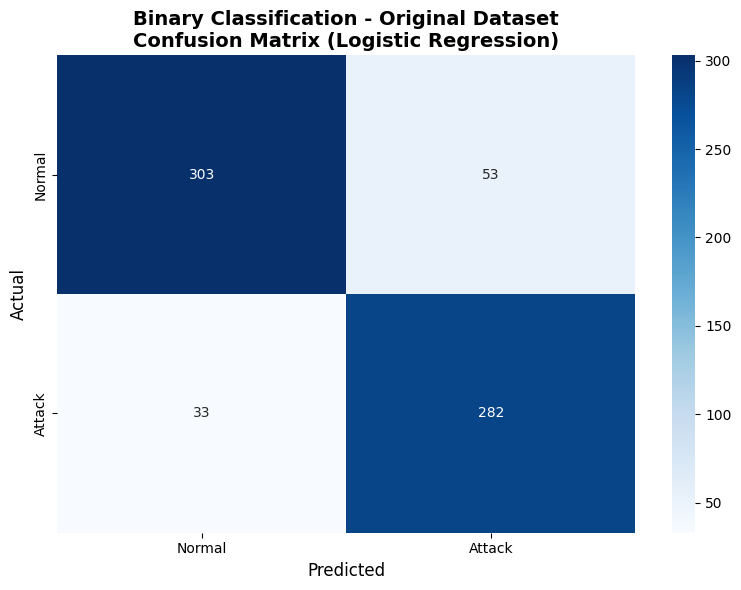

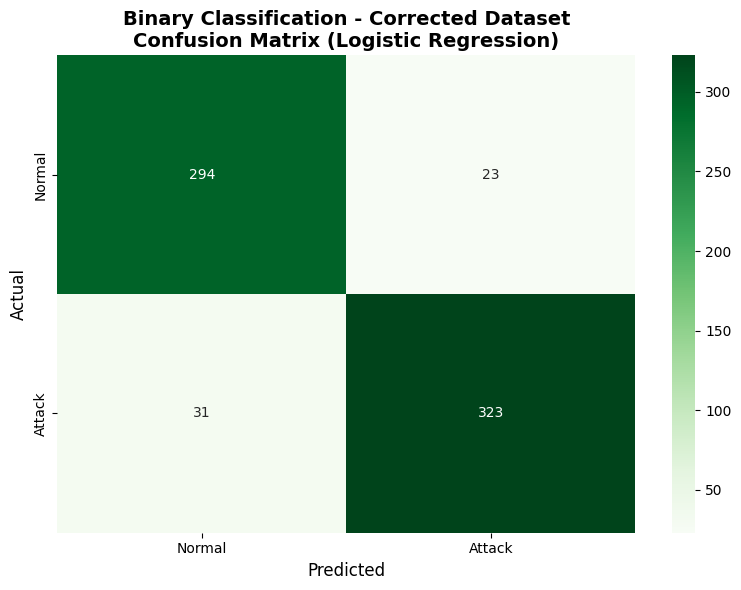

In [89]:
# 1. Binary Classification - Confusion Matrices Comparison
plt.figure(figsize=(8, 6))
sns.heatmap(results_orig_bin['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            cbar=True,
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Binary Classification - Original Dataset\nConfusion Matrix (Logistic Regression)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('logistic_regression_results/binary_classification_original_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 1.1 Binary Classification - Corrected Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(results_corr_bin['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            cbar=True,
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Binary Classification - Corrected Dataset\nConfusion Matrix (Logistic Regression)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('logistic_regression_results/binary_classification_corrected_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

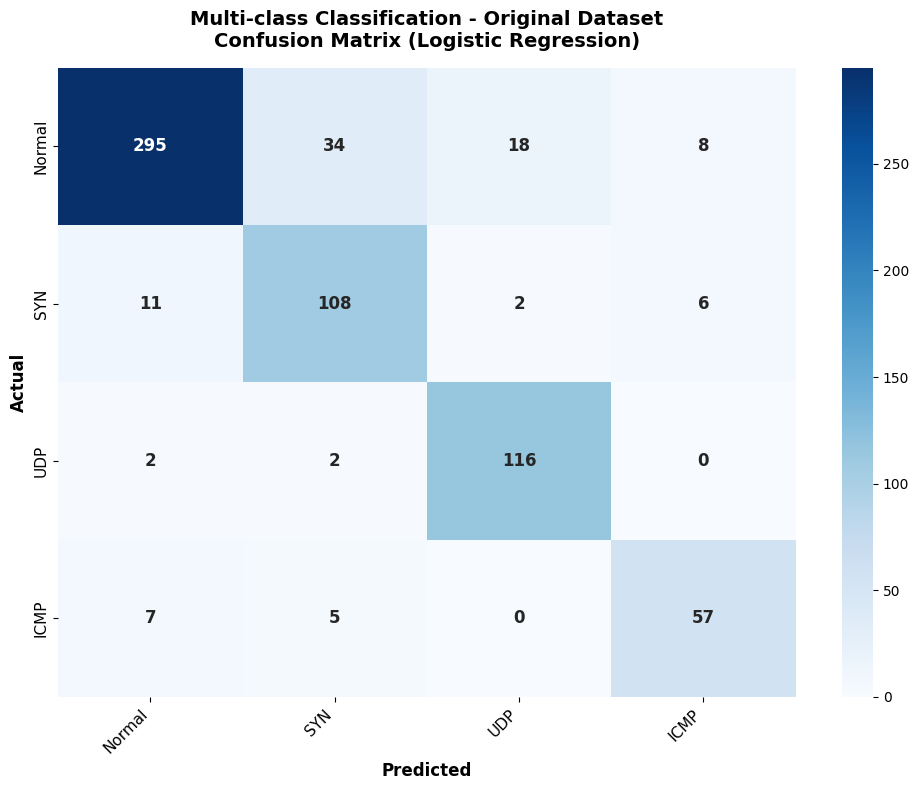

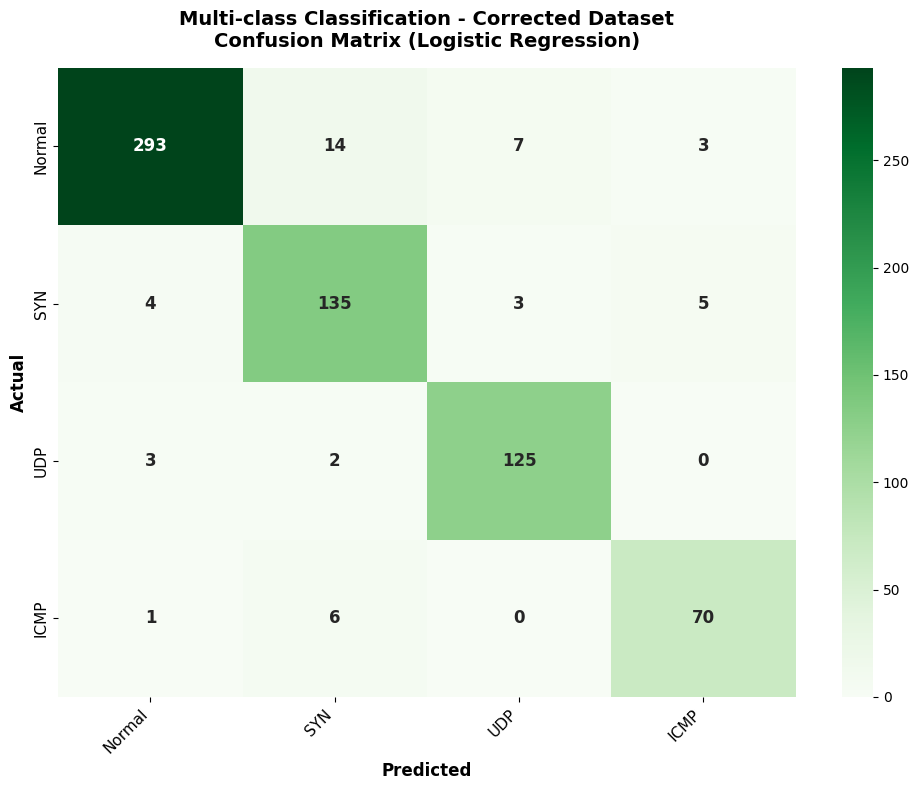

In [90]:
# 4. Multi-class - Original Dataset Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results_orig_multi['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=results_orig_multi['class_names'],
            yticklabels=results_orig_multi['class_names'],
            cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Multi-class Classification - Original Dataset\nConfusion Matrix (Logistic Regression)', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('logistic_regression_results/multi_class_classification_original_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.1 Multi-class - Corrected Dataset Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results_corr_multi['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=results_corr_multi['class_names'],
            yticklabels=results_corr_multi['class_names'],
            cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Multi-class Classification - Corrected Dataset\nConfusion Matrix (Logistic Regression)', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('logistic_regression_results/multi_class_classification_corrected_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

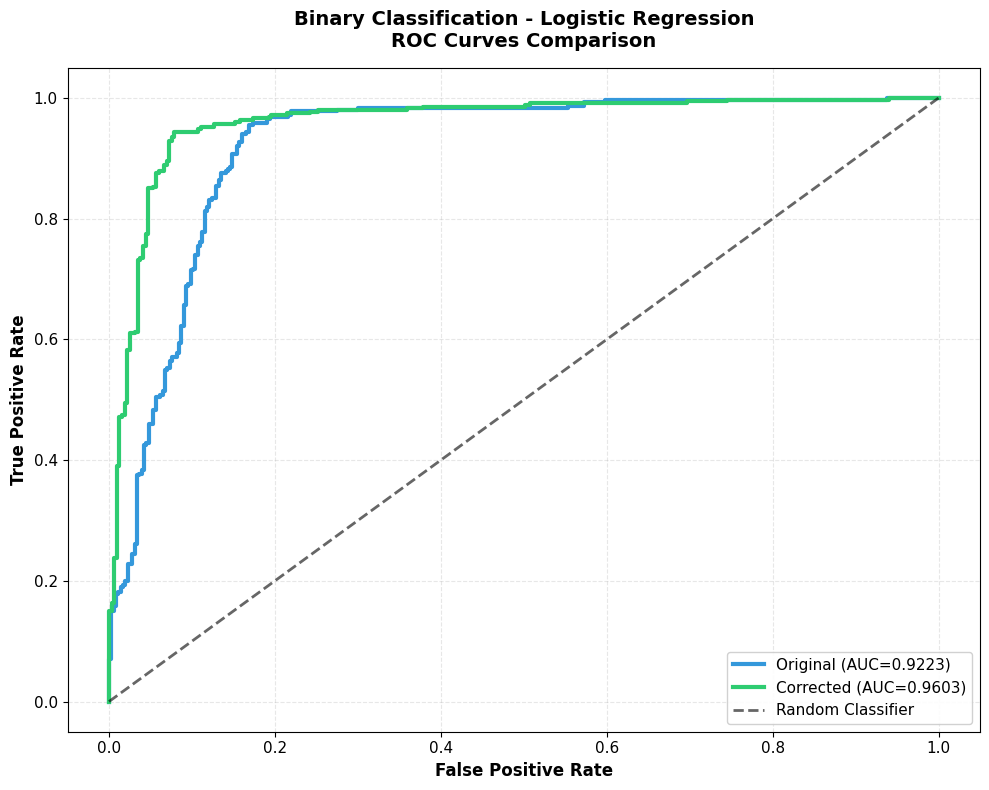

In [64]:
# 8. ROC Curves Comparison (Binary)
plt.figure(figsize=(10, 8))

fpr_orig, tpr_orig, _ = roc_curve(results_orig_bin['y_test'], results_orig_bin['y_pred_proba'])
fpr_corr, tpr_corr, _ = roc_curve(results_corr_bin['y_test'], results_corr_bin['y_pred_proba'])

plt.plot(fpr_orig, tpr_orig, linewidth=3, 
         label=f'Original (AUC={results_orig_bin["metrics"]["roc_auc"]:.4f})', 
         color=color_original, linestyle='-')
plt.plot(fpr_corr, tpr_corr, linewidth=3, 
         label=f'Corrected (AUC={results_corr_bin["metrics"]["roc_auc"]:.4f})', 
         color=color_corrected, linestyle='-')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.6)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Binary Classification - Logistic Regression\nROC Curves Comparison', 
          fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('logistic_regression_results/binary_classification_logistic_regression_roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

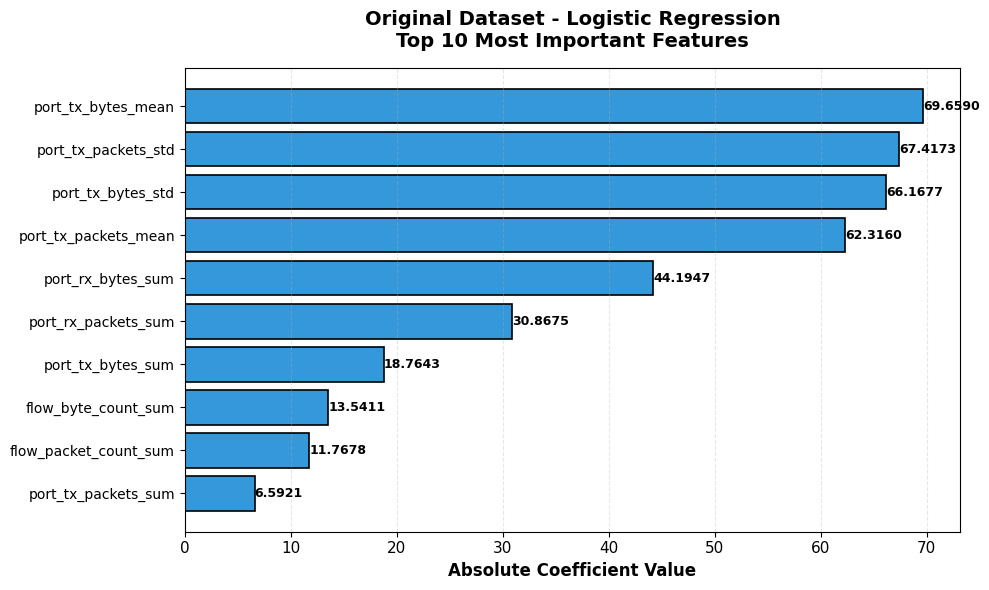

In [65]:
# 9. Feature Importance (Coefficients) Top 10 - Original
plt.figure(figsize=(10, 6))
top_features_orig = results_orig_bin['feature_importance'].head(10)
bars = plt.barh(range(len(top_features_orig)), top_features_orig['coefficient'], 
                color=color_original, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features_orig['coefficient'])):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2., 
            f'{val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.yticks(range(len(top_features_orig)), top_features_orig['feature'], fontsize=10)
plt.xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
plt.title('Original Dataset - Logistic Regression\nTop 10 Most Important Features', 
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('logistic_regression_results/original_dataset_logistic_regression_top10_important_features.png', dpi=300, bbox_inches='tight')
plt.show()

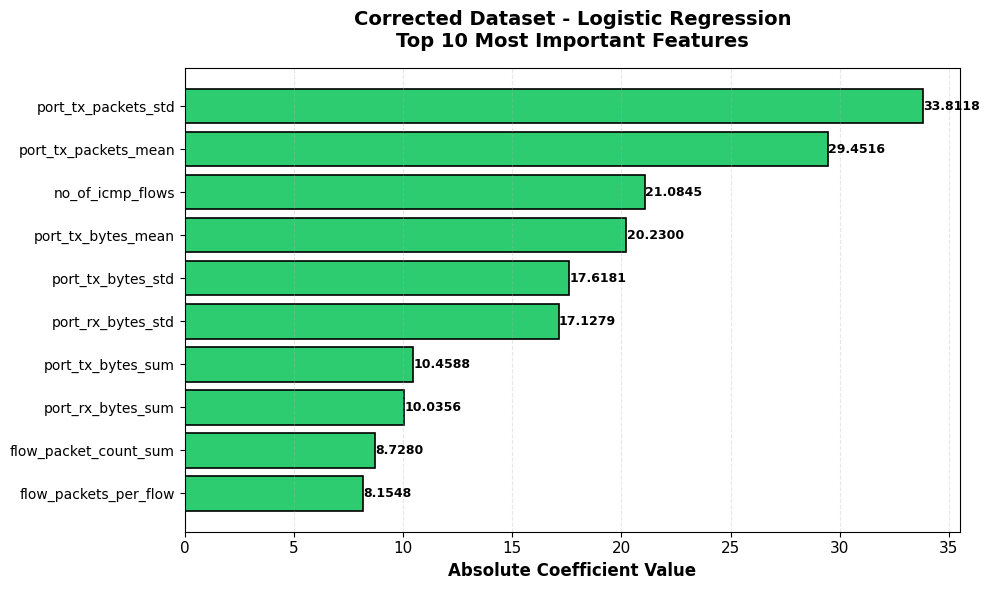

In [66]:
# 10. Feature Importance (Coefficients) Top 10 - Corrected
plt.figure(figsize=(10, 6))
top_features_corr = results_corr_bin['feature_importance'].head(10)
bars = plt.barh(range(len(top_features_corr)), top_features_corr['coefficient'], 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features_corr['coefficient'])):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2., 
            f'{val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.yticks(range(len(top_features_corr)), top_features_corr['feature'], fontsize=10)
plt.xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
plt.title('Corrected Dataset - Logistic Regression\nTop 10 Most Important Features', 
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('logistic_regression_results/corrected_dataset_logistic_regression_top10_important_features.png', dpi=300, bbox_inches='tight')
plt.show()

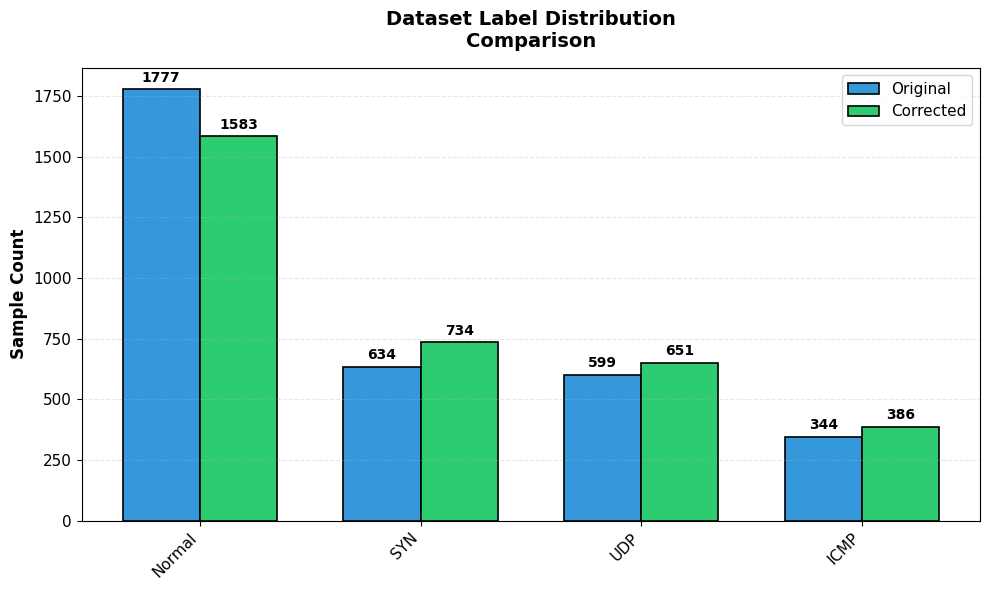

In [67]:
# 11. Dataset Label Distribution
plt.figure(figsize=(10, 6))
labels = ['Normal', 'SYN', 'UDP', 'ICMP']
orig_counts = [
    (df_original['attack'] == 0).sum(),
    df_original['attack_syn'].sum(),
    df_original['attack_udp'].sum(),
    df_original['attack_icmp'].sum()
]
corr_counts = [
    (df_corrected['attack'] == 0).sum(),
    df_corrected['attack_syn'].sum(),
    df_corrected['attack_udp'].sum(),
    df_corrected['attack_icmp'].sum()
]

x_pos = np.arange(len(labels))
width = 0.35

bars1 = plt.bar(x_pos - width/2, orig_counts, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, corr_counts, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Sample Count', fontsize=12, fontweight='bold')
plt.title('Dataset Label Distribution\nComparison', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, labels, rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('logistic_regression_results/dataset_label_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
# Export results to CSV

# Binary classification metrics
metrics_comparison_bin.to_csv('logistic_regression_results/binary_classification_comparison_logistic_regression.csv', index=False)

# Multi-class per-class metrics
multiclass_metrics = pd.DataFrame({
    'Class': results_orig_multi['class_names'],
    'Precision_Original': prec_orig,
    'Precision_Corrected': prec_corr,
    'Recall_Original': recall_orig,
    'Recall_Corrected': recall_corr
})
multiclass_metrics['Precision_Improvement'] = multiclass_metrics['Precision_Corrected'] - multiclass_metrics['Precision_Original']
multiclass_metrics['Recall_Improvement'] = multiclass_metrics['Recall_Corrected'] - multiclass_metrics['Recall_Original']

multiclass_metrics.to_csv('logistic_regression_results/multiclass_classification_comparison_logistic_regression.csv', index=False)

# Feature importance (coefficients)
results_orig_bin['feature_importance'].to_csv('logistic_regression_results/feature_importance_logistic_regression_original.csv', index=False)
results_corr_bin['feature_importance'].to_csv('logistic_regression_results/feature_importance_logistic_regression_corrected.csv', index=False)

In [70]:
from scipy import stats
from sklearn.utils import resample

def bootstrap_metric(y_true, y_pred, metric_func, n_iterations=1000, confidence=0.95):
    """
    Calculate bootstrap confidence interval for a metric.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        metric_func: Metric function to evaluate
        n_iterations: Number of bootstrap iterations
        confidence: Confidence level (default 0.95)
    
    Returns:
        (mean, lower_bound, upper_bound)
    """
    scores = []
    n_size = len(y_true)
    
    for i in range(n_iterations):
        # Bootstrap sample
        indices = resample(range(n_size), n_samples=n_size, replace=True)
        y_true_boot = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
        y_pred_boot = y_pred[indices]
        
        # Calculate metric
        score = metric_func(y_true_boot, y_pred_boot)
        scores.append(score)
    
    # Calculate confidence interval
    alpha = 1 - confidence
    lower = np.percentile(scores, (alpha/2) * 100)
    upper = np.percentile(scores, (1 - alpha/2) * 100)
    mean = np.mean(scores)
    
    return mean, lower, upper

In [71]:
# Binary Classification - 95% CI for Original Dataset
print("="*80)
print("BINARY CLASSIFICATION - ORIGINAL DATASET")
print("95% Confidence Intervals (Bootstrap, n=1000)")
print("="*80)

metrics_with_ci_orig = {}

# Accuracy
acc_mean, acc_lower, acc_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    accuracy_score
)
metrics_with_ci_orig['Accuracy'] = (acc_mean, acc_lower, acc_upper)
print(f"\nAccuracy:  {acc_mean:.4f} (95% CI: [{acc_lower:.4f}, {acc_upper:.4f}])")

# Precision
prec_mean, prec_lower, prec_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_orig['Precision'] = (prec_mean, prec_lower, prec_upper)
print(f"Precision: {prec_mean:.4f} (95% CI: [{prec_lower:.4f}, {prec_upper:.4f}])")

# Recall
rec_mean, rec_lower, rec_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_orig['Recall'] = (rec_mean, rec_lower, rec_upper)
print(f"Recall:    {rec_mean:.4f} (95% CI: [{rec_lower:.4f}, {rec_upper:.4f}])")

# F1-Score
f1_mean, f1_lower, f1_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_orig['F1-Score'] = (f1_mean, f1_lower, f1_upper)
print(f"F1-Score:  {f1_mean:.4f} (95% CI: [{f1_lower:.4f}, {f1_upper:.4f}])")

BINARY CLASSIFICATION - ORIGINAL DATASET
95% Confidence Intervals (Bootstrap, n=1000)

Accuracy:  0.8718 (95% CI: [0.8435, 0.8972])
Precision: 0.8424 (95% CI: [0.8042, 0.8795])
Recall:    0.8941 (95% CI: [0.8589, 0.9263])
F1-Score:  0.8671 (95% CI: [0.8392, 0.8932])


In [72]:
print("BINARY CLASSIFICATION - CORRECTED DATASET")
print("95% Confidence Intervals (Bootstrap, n=1000)")

metrics_with_ci_corr = {}

# Accuracy
acc_mean, acc_lower, acc_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    accuracy_score
)
metrics_with_ci_corr['Accuracy'] = (acc_mean, acc_lower, acc_upper)
print(f"\nAccuracy:  {acc_mean:.4f} (95% CI: [{acc_lower:.4f}, {acc_upper:.4f}])")

# Precision
prec_mean, prec_lower, prec_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_corr['Precision'] = (prec_mean, prec_lower, prec_upper)
print(f"Precision: {prec_mean:.4f} (95% CI: [{prec_lower:.4f}, {prec_upper:.4f}])")

# Recall
rec_mean, rec_lower, rec_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_corr['Recall'] = (rec_mean, rec_lower, rec_upper)
print(f"Recall:    {rec_mean:.4f} (95% CI: [{rec_lower:.4f}, {rec_upper:.4f}])")

# F1-Score
f1_mean, f1_lower, f1_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_corr['F1-Score'] = (f1_mean, f1_lower, f1_upper)
print(f"F1-Score:  {f1_mean:.4f} (95% CI: [{f1_lower:.4f}, {f1_upper:.4f}])")

BINARY CLASSIFICATION - CORRECTED DATASET
95% Confidence Intervals (Bootstrap, n=1000)

Accuracy:  0.9201 (95% CI: [0.9016, 0.9389])
Precision: 0.9340 (95% CI: [0.9067, 0.9567])
Recall:    0.9125 (95% CI: [0.8825, 0.9387])
F1-Score:  0.9231 (95% CI: [0.9004, 0.9435])


In [73]:
# Statistical Significance Testing
def bootstrap_difference_test(y_test1, y_pred1, y_test2, y_pred2, metric_func, n_iterations=1000):
    """
    Test if the difference between two independent models is statistically significant.
    Uses bootstrap to estimate the distribution of the difference.
    
    Returns:
        difference, p_value, is_significant, CI of difference
    """
    differences = []
    
    for i in range(n_iterations):
        # Bootstrap sample from each dataset independently
        n_size1 = len(y_test1)
        n_size2 = len(y_test2)
        
        indices1 = resample(range(n_size1), n_samples=n_size1, replace=True)
        indices2 = resample(range(n_size2), n_samples=n_size2, replace=True)
        
        y_test1_boot = y_test1.iloc[indices1] if hasattr(y_test1, 'iloc') else y_test1[indices1]
        y_pred1_boot = y_pred1[indices1]
        
        y_test2_boot = y_test2.iloc[indices2] if hasattr(y_test2, 'iloc') else y_test2[indices2]
        y_pred2_boot = y_pred2[indices2]
        
        # Calculate difference (Corrected - Original)
        score1 = metric_func(y_test1_boot, y_pred1_boot)
        score2 = metric_func(y_test2_boot, y_pred2_boot)
        differences.append(score2 - score1)
    
    # Calculate statistics
    mean_diff = np.mean(differences)
    ci_lower = np.percentile(differences, 2.5)
    ci_upper = np.percentile(differences, 97.5)
    
    # P-value: Check if 0 is within the 95% CI
    # If CI doesn't contain 0, the difference is significant
    is_significant = not (ci_lower <= 0 <= ci_upper)
    
    # Calculate p-value as proportion of bootstrap samples with opposite sign
    if mean_diff > 0:
        p_value = 2 * np.mean(np.array(differences) <= 0)
    else:
        p_value = 2 * np.mean(np.array(differences) >= 0)
    
    p_value = min(p_value, 1.0)  # Cap at 1.0
    
    return mean_diff, ci_lower, ci_upper, p_value, is_significant

In [74]:
print("="*80)
print("CORRECTED: STATISTICAL SIGNIFICANCE TESTING")
print("Independent Bootstrap Test (n=1000, α=0.05)")
print("="*80)

# Test for each metric
metrics_to_test = [
    ('Accuracy', accuracy_score),
    ('Precision', lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0)),
    ('Recall', lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0)),
    ('F1-Score', lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0))
]

significance_results_corrected = []

for metric_name, metric_func in metrics_to_test:
    diff, ci_low, ci_high, p_val, sig = bootstrap_difference_test(
        results_orig_bin['y_test'],
        results_orig_bin['y_pred'],
        results_corr_bin['y_test'],
        results_corr_bin['y_pred'],
        metric_func,
        n_iterations=1000
    )
    
    significance_results_corrected.append({
        'Metric': metric_name,
        'Difference': diff,
        'CI_Lower': ci_low,
        'CI_Upper': ci_high,
        'P-Value': p_val,
        'Significant': 'Yes' if sig else 'No'
    })
    
    sig_marker = "***" if sig else "n.s."
    print(f"{metric_name:10s}: Δ = {diff:+.4f} [95% CI: {ci_low:+.4f}, {ci_high:+.4f}], p = {p_val:.4f} {sig_marker}")

print("\n*** p < 0.05 (statistically significant)")
print("n.s. not significant")

CORRECTED: STATISTICAL SIGNIFICANCE TESTING
Independent Bootstrap Test (n=1000, α=0.05)
Accuracy  : Δ = +0.0477 [95% CI: +0.0149, +0.0760], p = 0.0080 ***
Precision : Δ = +0.0912 [95% CI: +0.0431, +0.1357], p = 0.0000 ***
Recall    : Δ = +0.0183 [95% CI: -0.0284, +0.0615], p = 0.4020 n.s.
F1-Score  : Δ = +0.0562 [95% CI: +0.0225, +0.0926], p = 0.0060 ***

*** p < 0.05 (statistically significant)
n.s. not significant


In [75]:
# Per-Class Confidence Intervals (Multi-class)
print("="*80)
print("MULTI-CLASS: PER-CLASS METRICS WITH 95% CI")
print("="*80)

class_names = results_orig_multi['class_names']

for class_idx, class_name in enumerate(class_names):
    print(f"\n{class_name.upper()}:")
    print("-" * 40)
    
    # Create binary labels for this class
    y_test_orig_binary = (results_orig_multi['y_test'] == class_idx).astype(int)
    y_pred_orig_binary = (results_orig_multi['y_pred'] == class_idx).astype(int)
    
    y_test_corr_binary = (results_corr_multi['y_test'] == class_idx).astype(int)
    y_pred_corr_binary = (results_corr_multi['y_pred'] == class_idx).astype(int)
    
    # Precision - Original
    prec_orig_mean, prec_orig_lower, prec_orig_upper = bootstrap_metric(
        y_test_orig_binary,
        y_pred_orig_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    # Precision - Corrected
    prec_corr_mean, prec_corr_lower, prec_corr_upper = bootstrap_metric(
        y_test_corr_binary,
        y_pred_corr_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    print(f"  Precision:")
    print(f"    Original:  {prec_orig_mean:.4f} [{prec_orig_lower:.4f}, {prec_orig_upper:.4f}]")
    print(f"    Corrected: {prec_corr_mean:.4f} [{prec_corr_lower:.4f}, {prec_corr_upper:.4f}]")
    
    # Recall - Original
    rec_orig_mean, rec_orig_lower, rec_orig_upper = bootstrap_metric(
        y_test_orig_binary,
        y_pred_orig_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    # Recall - Corrected
    rec_corr_mean, rec_corr_lower, rec_corr_upper = bootstrap_metric(
        y_test_corr_binary,
        y_pred_corr_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    print(f"  Recall:")
    print(f"    Original:  {rec_orig_mean:.4f} [{rec_orig_lower:.4f}, {rec_orig_upper:.4f}]")
    print(f"    Corrected: {rec_corr_mean:.4f} [{rec_corr_lower:.4f}, {rec_corr_upper:.4f}]")

MULTI-CLASS: PER-CLASS METRICS WITH 95% CI

NORMAL:
----------------------------------------
  Precision:
    Original:  0.9356 [0.9113, 0.9618]
    Corrected: 0.9734 [0.9548, 0.9901]
  Recall:
    Original:  0.8308 [0.7923, 0.8686]
    Corrected: 0.9245 [0.8942, 0.9513]

SYN:
----------------------------------------
  Precision:
    Original:  0.7248 [0.6481, 0.7959]
    Corrected: 0.8601 [0.8049, 0.9161]
  Recall:
    Original:  0.8507 [0.7887, 0.9063]
    Corrected: 0.9174 [0.8713, 0.9564]

UDP:
----------------------------------------
  Precision:
    Original:  0.8530 [0.7922, 0.9102]
    Corrected: 0.9268 [0.8825, 0.9647]
  Recall:
    Original:  0.9664 [0.9319, 0.9923]
    Corrected: 0.9609 [0.9277, 0.9910]

ICMP:
----------------------------------------
  Precision:
    Original:  0.8083 [0.7259, 0.8993]
    Corrected: 0.8984 [0.8332, 0.9603]
  Recall:
    Original:  0.8216 [0.7267, 0.9051]
    Corrected: 0.9077 [0.8391, 0.9645]


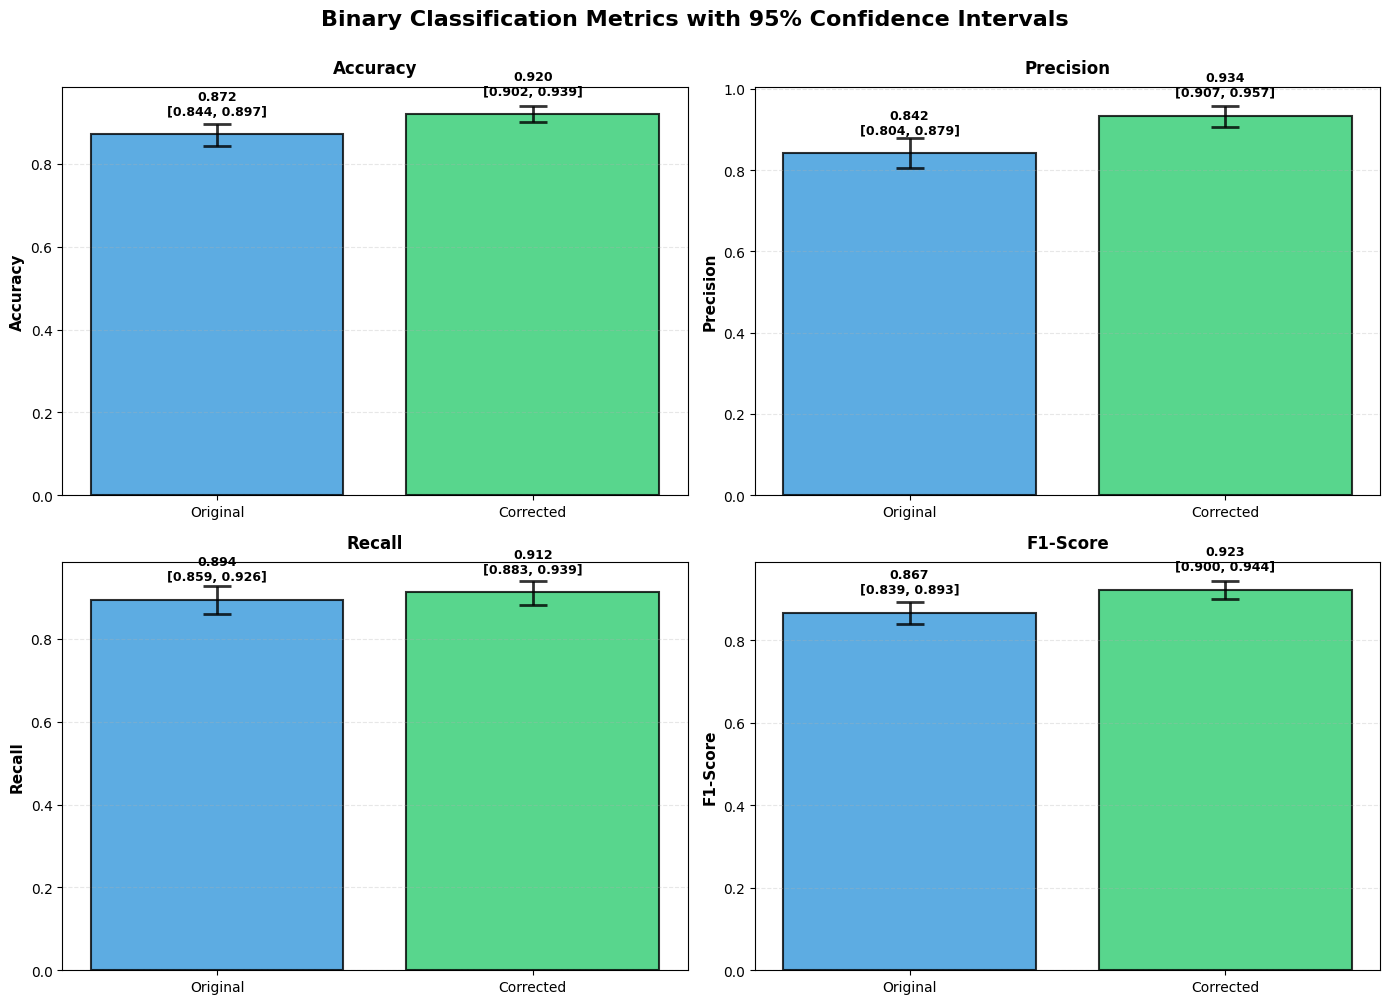

In [94]:
# Visualization:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Binary Classification Metrics with 95% Confidence Intervals', 
             fontsize=16, fontweight='bold', y=1.00)

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (ax, metric_name) in enumerate(zip(axes.flat, metrics_list)):
    orig_mean, orig_lower, orig_upper = metrics_with_ci_orig[metric_name]
    corr_mean, corr_lower, corr_upper = metrics_with_ci_corr[metric_name]
    
    datasets = ['Original', 'Corrected']
    means = [orig_mean, corr_mean]
    lowers = [orig_lower, corr_lower]
    uppers = [orig_upper, corr_upper]
    
    # Calculate error bars
    yerr_lower = [means[i] - lowers[i] for i in range(2)]
    yerr_upper = [uppers[i] - means[i] for i in range(2)]
    
    x_pos = np.arange(len(datasets))
    bars = ax.bar(x_pos, means, 
                  color=[color_original, color_corrected],
                  edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Add error bars
    ax.errorbar(x_pos, means, 
                yerr=[yerr_lower, yerr_upper],
                fmt='none', ecolor='black', capsize=10, 
                capthick=2, linewidth=2, alpha=0.8)
    
    # Add value labels
    for i, (bar, mean, lower, upper) in enumerate(zip(bars, means, lowers, uppers)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.04,
                f'{mean:.3f}\n[{lower:.3f}, {upper:.3f}]',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(datasets, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('logistic_regression_results/binary_metrics_with_95_ci.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [77]:
# Export Statistical Results to CSV
ci_results_binary = []

for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    orig_mean, orig_lower, orig_upper = metrics_with_ci_orig[metric_name]
    corr_mean, corr_lower, corr_upper = metrics_with_ci_corr[metric_name]
    
    ci_results_binary.append({
        'Metric': metric_name,
        'Original_Mean': orig_mean,
        'Original_CI_Lower': orig_lower,
        'Original_CI_Upper': orig_upper,
        'Original_CI_Width': orig_upper - orig_lower,
        'Corrected_Mean': corr_mean,
        'Corrected_CI_Lower': corr_lower,
        'Corrected_CI_Upper': corr_upper,
        'Corrected_CI_Width': corr_upper - corr_lower,
        'Improvement': corr_mean - orig_mean
    })

df_ci_binary = pd.DataFrame(ci_results_binary)
df_ci_binary.to_csv('logistic_regression_results/binary_metrics_95ci_logistic_regression.csv', 
                     index=False)

# Statistical significance results
df_significance = pd.DataFrame(significance_results_corrected)
df_significance.to_csv('logistic_regression_results/statistical_significance_tests.csv', 
                        index=False)

In [78]:
# Summary Table: All Metrics with CI
print("="*100)
print("COMPREHENSIVE SUMMARY: BINARY CLASSIFICATION WITH 95% CONFIDENCE INTERVALS")
print("="*100)

summary_df = pd.DataFrame({
    'Metric': [],
    'Original': [],
    'Original_95%_CI': [],
    'Corrected': [],
    'Corrected_95%_CI': [],
    'Improvement': [],
    'P-Value': [],
    'Significant': []
})

for i, metric_name in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-Score']):
    orig_mean, orig_lower, orig_upper = metrics_with_ci_orig[metric_name]
    corr_mean, corr_lower, corr_upper = metrics_with_ci_corr[metric_name]
    
    summary_df = pd.concat([summary_df, pd.DataFrame({
        'Metric': [metric_name],
        'Original': [f'{orig_mean:.4f}'],
        'Original_95%_CI': [f'[{orig_lower:.4f}, {orig_upper:.4f}]'],
        'Corrected': [f'{corr_mean:.4f}'],
        'Corrected_95%_CI': [f'[{corr_lower:.4f}, {corr_upper:.4f}]'],
        'Improvement': [f'{corr_mean - orig_mean:+.4f}'],
        'P-Value': [f'{significance_results_corrected[i]["P-Value"]:.4f}'],
        'Significant': [significance_results_corrected[i]['Significant']]
    })], ignore_index=True)

print(summary_df.to_string(index=False))

COMPREHENSIVE SUMMARY: BINARY CLASSIFICATION WITH 95% CONFIDENCE INTERVALS
   Metric Original  Original_95%_CI Corrected Corrected_95%_CI Improvement P-Value Significant
 Accuracy   0.8718 [0.8435, 0.8972]    0.9201 [0.9016, 0.9389]     +0.0483  0.0080         Yes
Precision   0.8424 [0.8042, 0.8795]    0.9340 [0.9067, 0.9567]     +0.0916  0.0000         Yes
   Recall   0.8941 [0.8589, 0.9263]    0.9125 [0.8825, 0.9387]     +0.0184  0.4020          No
 F1-Score   0.8671 [0.8392, 0.8932]    0.9231 [0.9004, 0.9435]     +0.0559  0.0060         Yes


In [79]:
# Calculate Per-Class Metrics with 95% CI for Visualization
class_names = results_orig_multi['class_names']
n_classes = len(class_names)

# Storage for per-class metrics with CI
per_class_metrics_orig = {
    'precision': {'mean': [], 'lower': [], 'upper': []},
    'recall': {'mean': [], 'lower': [], 'upper': []}
}

per_class_metrics_corr = {
    'precision': {'mean': [], 'lower': [], 'upper': []},
    'recall': {'mean': [], 'lower': [], 'upper': []}
}

for class_idx in range(n_classes):
    # Original dataset
    y_test_orig_binary = (results_orig_multi['y_test'] == class_idx).astype(int)
    y_pred_orig_binary = (results_orig_multi['y_pred'] == class_idx).astype(int)
    
    # Corrected dataset
    y_test_corr_binary = (results_corr_multi['y_test'] == class_idx).astype(int)
    y_pred_corr_binary = (results_corr_multi['y_pred'] == class_idx).astype(int)
    
    # Precision - Original
    prec_orig_mean, prec_orig_lower, prec_orig_upper = bootstrap_metric(
        y_test_orig_binary, y_pred_orig_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_orig['precision']['mean'].append(prec_orig_mean)
    per_class_metrics_orig['precision']['lower'].append(prec_orig_lower)
    per_class_metrics_orig['precision']['upper'].append(prec_orig_upper)
    
    # Precision - Corrected
    prec_corr_mean, prec_corr_lower, prec_corr_upper = bootstrap_metric(
        y_test_corr_binary, y_pred_corr_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_corr['precision']['mean'].append(prec_corr_mean)
    per_class_metrics_corr['precision']['lower'].append(prec_corr_lower)
    per_class_metrics_corr['precision']['upper'].append(prec_corr_upper)
    
    # Recall - Original
    rec_orig_mean, rec_orig_lower, rec_orig_upper = bootstrap_metric(
        y_test_orig_binary, y_pred_orig_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_orig['recall']['mean'].append(rec_orig_mean)
    per_class_metrics_orig['recall']['lower'].append(rec_orig_lower)
    per_class_metrics_orig['recall']['upper'].append(rec_orig_upper)
    
    # Recall - Corrected
    rec_corr_mean, rec_corr_lower, rec_corr_upper = bootstrap_metric(
        y_test_corr_binary, y_pred_corr_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_corr['recall']['mean'].append(rec_corr_mean)
    per_class_metrics_corr['recall']['lower'].append(rec_corr_lower)
    per_class_metrics_corr['recall']['upper'].append(rec_corr_upper)

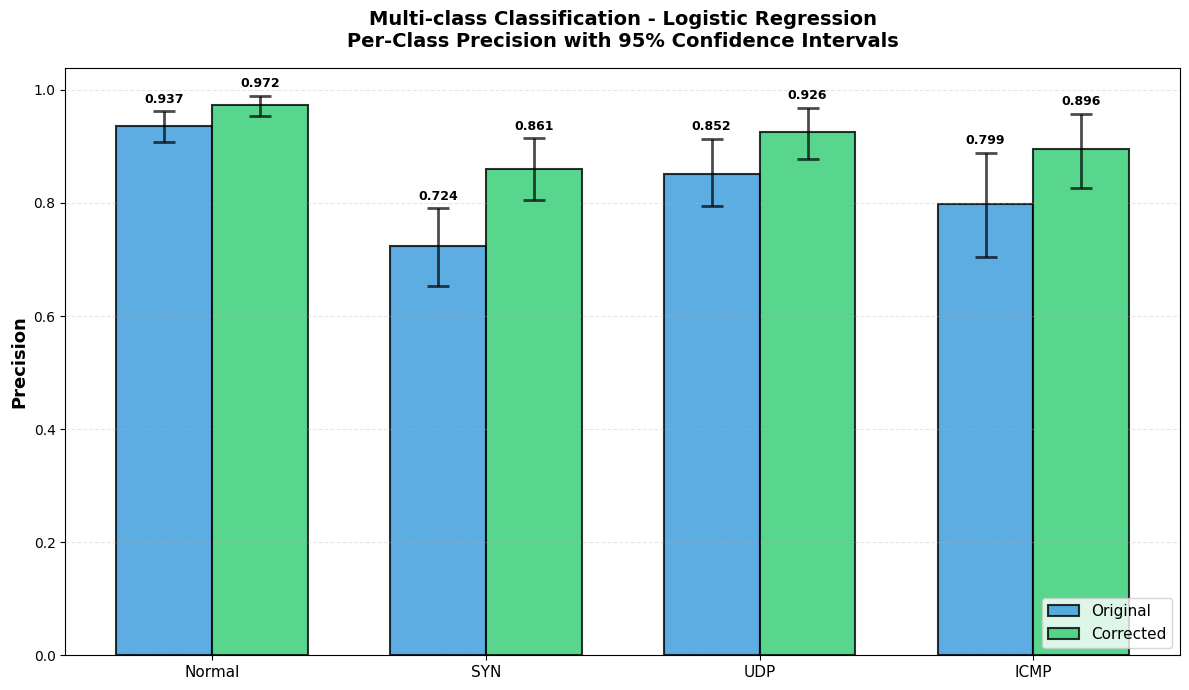

In [96]:
# Visualization 1: Per-Class Precision with 95% CI
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(class_names))
width = 0.35

# Original dataset
orig_means = per_class_metrics_orig['precision']['mean']
orig_lowers = per_class_metrics_orig['precision']['lower']
orig_uppers = per_class_metrics_orig['precision']['upper']
orig_yerr_lower = [orig_means[i] - orig_lowers[i] for i in range(n_classes)]
orig_yerr_upper = [orig_uppers[i] - orig_means[i] for i in range(n_classes)]

bars1 = ax.bar(x_pos - width/2, orig_means, width,
               label='Original', color=color_original,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos - width/2, orig_means,
            yerr=[orig_yerr_lower, orig_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Corrected dataset
corr_means = per_class_metrics_corr['precision']['mean']
corr_lowers = per_class_metrics_corr['precision']['lower']
corr_uppers = per_class_metrics_corr['precision']['upper']
corr_yerr_lower = [corr_means[i] - corr_lowers[i] for i in range(n_classes)]
corr_yerr_upper = [corr_uppers[i] - corr_means[i] for i in range(n_classes)]

bars2 = ax.bar(x_pos + width/2, corr_means, width,
               label='Corrected', color=color_corrected,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos + width/2, corr_means,
            yerr=[corr_yerr_lower, corr_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Add value labels
for i in range(n_classes):
    # Original
    ax.text(x_pos[i] - width/2, orig_means[i] + orig_yerr_upper[i] + 0.01,
            f'{orig_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Corrected
    ax.text(x_pos[i] + width/2, corr_means[i] + corr_yerr_upper[i] + 0.01,
            f'{corr_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Logistic Regression\nPer-Class Precision with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('logistic_regression_results/multiclass_precision_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

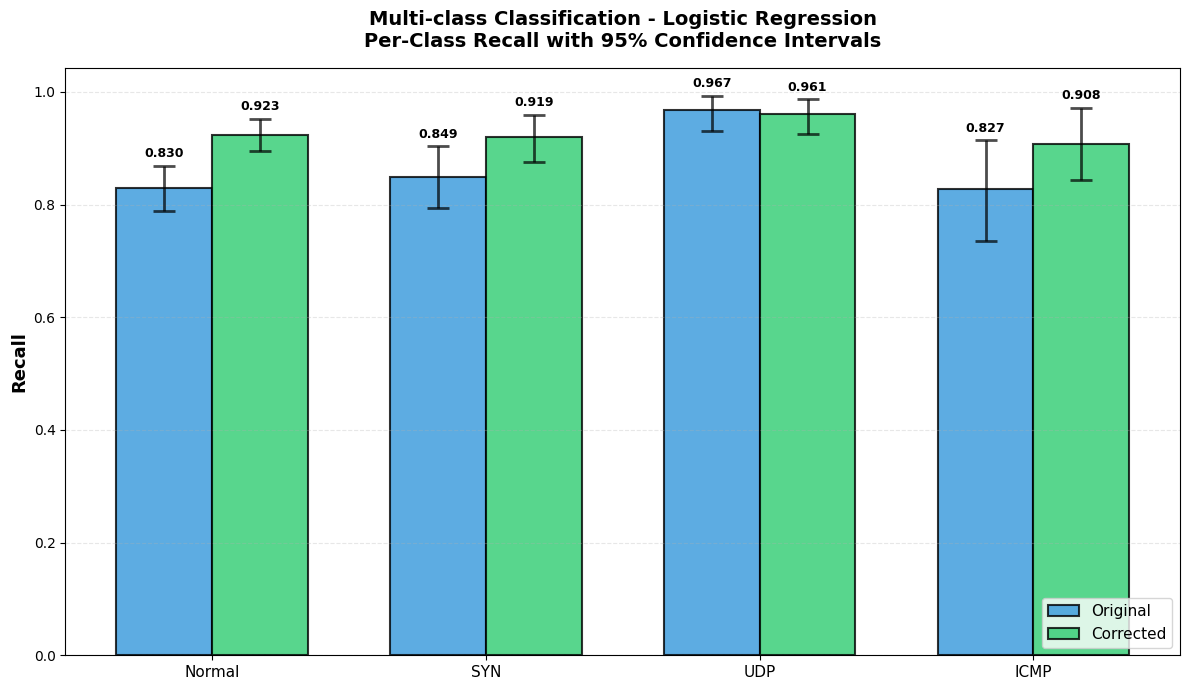

In [97]:
# Visualization 2: Per-Class Recall with 95% CI
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(class_names))
width = 0.35

# Original dataset
orig_means = per_class_metrics_orig['recall']['mean']
orig_lowers = per_class_metrics_orig['recall']['lower']
orig_uppers = per_class_metrics_orig['recall']['upper']
orig_yerr_lower = [orig_means[i] - orig_lowers[i] for i in range(n_classes)]
orig_yerr_upper = [orig_uppers[i] - orig_means[i] for i in range(n_classes)]

bars1 = ax.bar(x_pos - width/2, orig_means, width,
               label='Original', color=color_original,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos - width/2, orig_means,
            yerr=[orig_yerr_lower, orig_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Corrected dataset
corr_means = per_class_metrics_corr['recall']['mean']
corr_lowers = per_class_metrics_corr['recall']['lower']
corr_uppers = per_class_metrics_corr['recall']['upper']
corr_yerr_lower = [corr_means[i] - corr_lowers[i] for i in range(n_classes)]
corr_yerr_upper = [corr_uppers[i] - corr_means[i] for i in range(n_classes)]

bars2 = ax.bar(x_pos + width/2, corr_means, width,
               label='Corrected', color=color_corrected,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos + width/2, corr_means,
            yerr=[corr_yerr_lower, corr_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Add value labels
for i in range(n_classes):
    # Original
    ax.text(x_pos[i] - width/2, orig_means[i] + orig_yerr_upper[i] + 0.01,
            f'{orig_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Corrected
    ax.text(x_pos[i] + width/2, corr_means[i] + corr_yerr_upper[i] + 0.01,
            f'{corr_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Recall', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Logistic Regression\nPer-Class Recall with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('logistic_regression_results/multiclass_recall_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [99]:
# Calculate confidence intervals for multi-class accuracy
# Original dataset
acc_orig_mean, acc_orig_lower, acc_orig_upper = bootstrap_metric(
    results_orig_multi['y_test'],
    results_orig_multi['y_pred'],
    accuracy_score,
    n_iterations=1000
)

# Corrected dataset
acc_corr_mean, acc_corr_lower, acc_corr_upper = bootstrap_metric(
    results_corr_multi['y_test'],
    results_corr_multi['y_pred'],
    accuracy_score,
    n_iterations=1000
)

# Test significance
diff_multi, ci_low_multi, ci_high_multi, p_val_multi, sig_multi = bootstrap_difference_test(
    results_orig_multi['y_test'],
    results_orig_multi['y_pred'],
    results_corr_multi['y_test'],
    results_corr_multi['y_pred'],
    accuracy_score,
    n_iterations=1000
)

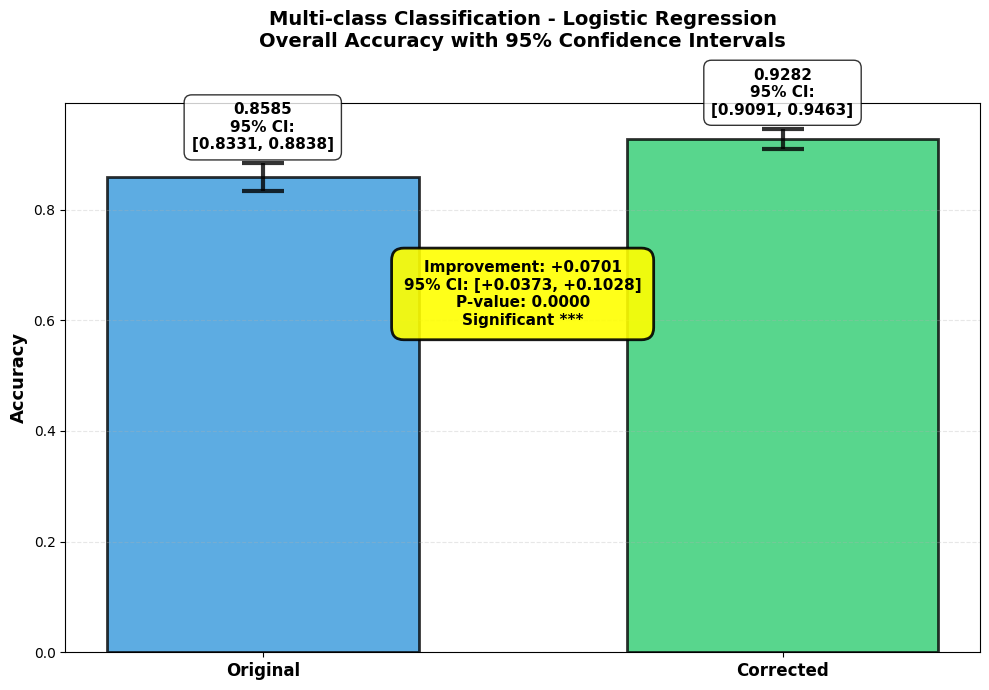


Original Accuracy:  0.8585 [95% CI: 0.8331, 0.8838]
Corrected Accuracy: 0.9282 [95% CI: 0.9091, 0.9463]
Improvement: +0.0701 [95% CI: +0.0373, +0.1028]
P-value: 0.0000 ***


In [101]:
# Visualization 3: Overall Accuracy with 95% CI (Multi-class)
fig, ax = plt.subplots(figsize=(10, 7))

datasets = ['Original', 'Corrected']
means = [acc_orig_mean, acc_corr_mean]
lowers = [acc_orig_lower, acc_corr_lower]
uppers = [acc_orig_upper, acc_corr_upper]

yerr_lower = [means[i] - lowers[i] for i in range(2)]
yerr_upper = [uppers[i] - means[i] for i in range(2)]

x_pos = np.arange(len(datasets))

bars = ax.bar(x_pos, means,
              color=[color_original, color_corrected],
              edgecolor='black', linewidth=2, alpha=0.8, width=0.6)

ax.errorbar(x_pos, means,
            yerr=[yerr_lower, yerr_upper],
            fmt='none', ecolor='black', capsize=15,
            capthick=3, linewidth=3, alpha=0.8)

# Add value labels with CI
for i, (bar, mean, lower, upper) in enumerate(zip(bars, means, lowers, uppers)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + yerr_upper[i] + 0.02,
            f'{mean:.4f}\n95% CI:\n[{lower:.4f}, {upper:.4f}]',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='black', alpha=0.8))

# Add improvement annotation
improvement_text = (f'Improvement: {diff_multi:+.4f}\n'
                   f'95% CI: [{ci_low_multi:+.4f}, {ci_high_multi:+.4f}]\n'
                   f'P-value: {p_val_multi:.4f}\n'
                   f'{"Significant ***" if sig_multi else "Not Significant"}')

ax.text(0.5, min(means) - 0.15, improvement_text,
        ha='center', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', 
                 facecolor='yellow' if sig_multi else 'lightgray',
                 edgecolor='black', linewidth=2, alpha=0.9))

ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Logistic Regression\nOverall Accuracy with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=40)
ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('logistic_regression_results/multiclass_accuracy_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOriginal Accuracy:  {acc_orig_mean:.4f} [95% CI: {acc_orig_lower:.4f}, {acc_orig_upper:.4f}]")
print(f"Corrected Accuracy: {acc_corr_mean:.4f} [95% CI: {acc_corr_lower:.4f}, {acc_corr_upper:.4f}]")
print(f"Improvement: {diff_multi:+.4f} [95% CI: {ci_low_multi:+.4f}, {ci_high_multi:+.4f}]")
print(f"P-value: {p_val_multi:.4f} {'***' if sig_multi else 'n.s.'}")

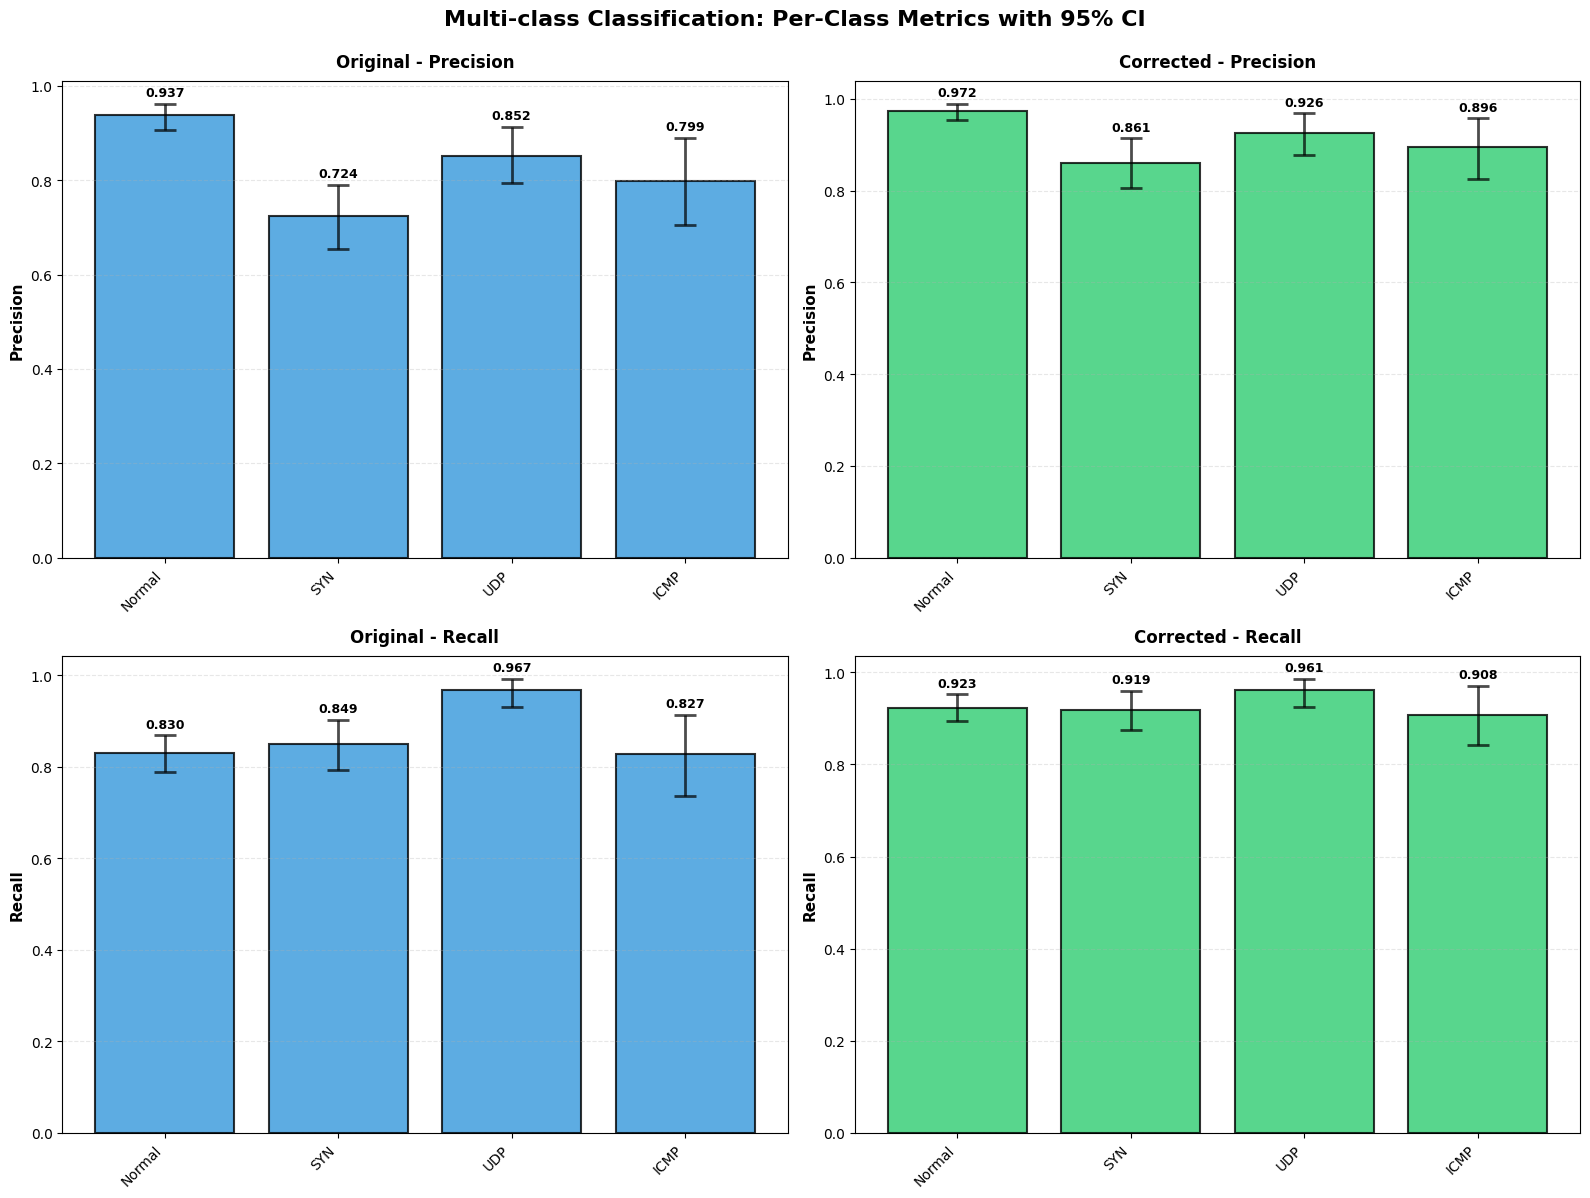

In [104]:
# Visualization 4: Combined Per-Class Metrics (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-class Classification: Per-Class Metrics with 95% CI',
             fontsize=16, fontweight='bold', y=0.995)

metrics_to_plot = ['precision', 'recall']
datasets_labels = ['Original', 'Corrected']

for row_idx, metric_name in enumerate(metrics_to_plot):
    for col_idx, dataset_label in enumerate(datasets_labels):
        ax = axes[row_idx, col_idx]
        
        # Select data
        if dataset_label == 'Original':
            means = per_class_metrics_orig[metric_name]['mean']
            lowers = per_class_metrics_orig[metric_name]['lower']
            uppers = per_class_metrics_orig[metric_name]['upper']
            color = color_original
        else:
            means = per_class_metrics_corr[metric_name]['mean']
            lowers = per_class_metrics_corr[metric_name]['lower']
            uppers = per_class_metrics_corr[metric_name]['upper']
            color = color_corrected
        
        yerr_lower = [means[i] - lowers[i] for i in range(n_classes)]
        yerr_upper = [uppers[i] - means[i] for i in range(n_classes)]
        
        x_pos = np.arange(n_classes)
        
        bars = ax.bar(x_pos, means, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)
        
        ax.errorbar(x_pos, means,
                   yerr=[yerr_lower, yerr_upper],
                   fmt='none', ecolor='black', capsize=8,
                   capthick=2, linewidth=2, alpha=0.7)
        
        # Add value labels
        for i in range(n_classes):
            ax.text(x_pos[i], means[i] + yerr_upper[i] + 0.01,
                   f'{means[i]:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_ylabel(metric_name.capitalize(), fontsize=11, fontweight='bold')
        ax.set_title(f'{dataset_label} - {metric_name.capitalize()}',
                    fontsize=12, fontweight='bold', pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(class_names, fontsize=10, rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('logistic_regression_results/multiclass_all_metrics_grid_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

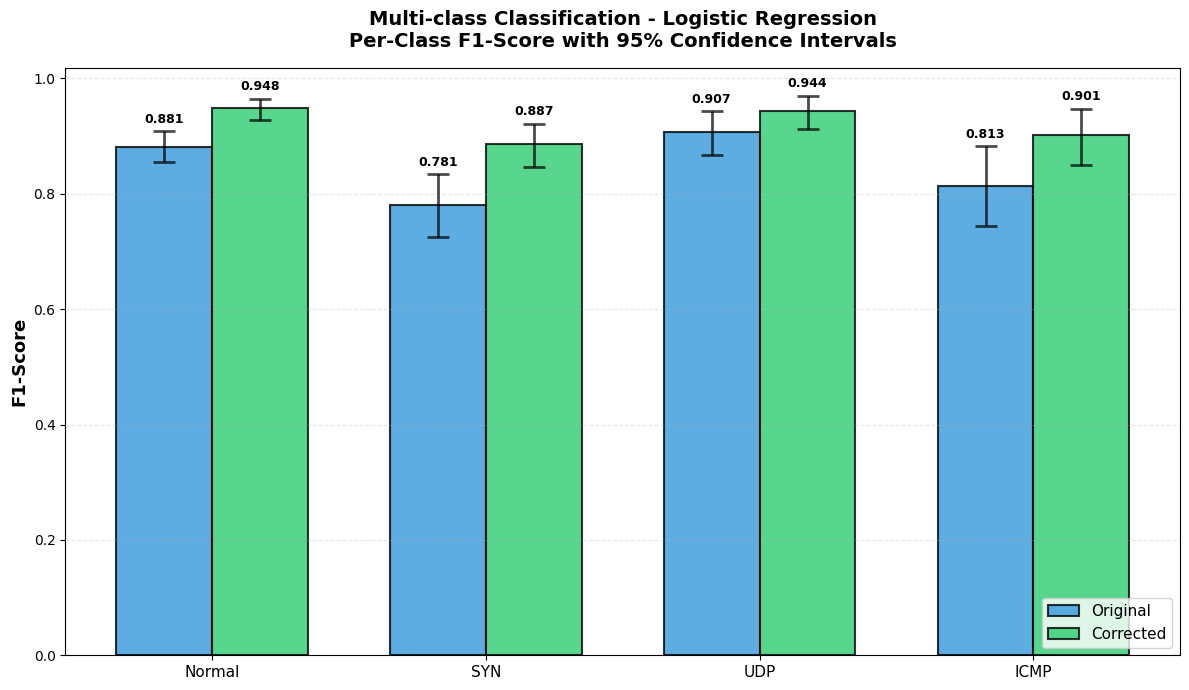

In [105]:
# Visualization 5: Per-Class F1-Score with 95% CI
per_class_f1_orig = {'mean': [], 'lower': [], 'upper': []}
per_class_f1_corr = {'mean': [], 'lower': [], 'upper': []}

for class_idx in range(n_classes):
    # Original dataset
    y_test_orig_binary = (results_orig_multi['y_test'] == class_idx).astype(int)
    y_pred_orig_binary = (results_orig_multi['y_pred'] == class_idx).astype(int)
    
    # Corrected dataset
    y_test_corr_binary = (results_corr_multi['y_test'] == class_idx).astype(int)
    y_pred_corr_binary = (results_corr_multi['y_pred'] == class_idx).astype(int)
    
    # F1 - Original
    f1_orig_mean, f1_orig_lower, f1_orig_upper = bootstrap_metric(
        y_test_orig_binary, y_pred_orig_binary,
        lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_f1_orig['mean'].append(f1_orig_mean)
    per_class_f1_orig['lower'].append(f1_orig_lower)
    per_class_f1_orig['upper'].append(f1_orig_upper)
    
    # F1 - Corrected
    f1_corr_mean, f1_corr_lower, f1_corr_upper = bootstrap_metric(
        y_test_corr_binary, y_pred_corr_binary,
        lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_f1_corr['mean'].append(f1_corr_mean)
    per_class_f1_corr['lower'].append(f1_corr_lower)
    per_class_f1_corr['upper'].append(f1_corr_upper)

# Plot F1-Score
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(class_names))
width = 0.35

# Original dataset
orig_means = per_class_f1_orig['mean']
orig_lowers = per_class_f1_orig['lower']
orig_uppers = per_class_f1_orig['upper']
orig_yerr_lower = [orig_means[i] - orig_lowers[i] for i in range(n_classes)]
orig_yerr_upper = [orig_uppers[i] - orig_means[i] for i in range(n_classes)]

bars1 = ax.bar(x_pos - width/2, orig_means, width,
               label='Original', color=color_original,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos - width/2, orig_means,
            yerr=[orig_yerr_lower, orig_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Corrected dataset
corr_means = per_class_f1_corr['mean']
corr_lowers = per_class_f1_corr['lower']
corr_uppers = per_class_f1_corr['upper']
corr_yerr_lower = [corr_means[i] - corr_lowers[i] for i in range(n_classes)]
corr_yerr_upper = [corr_uppers[i] - corr_means[i] for i in range(n_classes)]

bars2 = ax.bar(x_pos + width/2, corr_means, width,
               label='Corrected', color=color_corrected,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos + width/2, corr_means,
            yerr=[corr_yerr_lower, corr_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Add value labels
for i in range(n_classes):
    # Original
    ax.text(x_pos[i] - width/2, orig_means[i] + orig_yerr_upper[i] + 0.01,
            f'{orig_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Corrected
    ax.text(x_pos[i] + width/2, corr_means[i] + corr_yerr_upper[i] + 0.01,
            f'{corr_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Logistic Regression\nPer-Class F1-Score with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('logistic_regression_results/multiclass_f1score_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [85]:
# Export Multi-class Per-Class Results with CI to CSV
multiclass_perclass_ci = []

for class_idx, class_name in enumerate(class_names):
    multiclass_perclass_ci.append({
        'Class': class_name,
        'Precision_Original_Mean': per_class_metrics_orig['precision']['mean'][class_idx],
        'Precision_Original_CI_Lower': per_class_metrics_orig['precision']['lower'][class_idx],
        'Precision_Original_CI_Upper': per_class_metrics_orig['precision']['upper'][class_idx],
        'Precision_Corrected_Mean': per_class_metrics_corr['precision']['mean'][class_idx],
        'Precision_Corrected_CI_Lower': per_class_metrics_corr['precision']['lower'][class_idx],
        'Precision_Corrected_CI_Upper': per_class_metrics_corr['precision']['upper'][class_idx],
        'Precision_Improvement': (per_class_metrics_corr['precision']['mean'][class_idx] - 
                                 per_class_metrics_orig['precision']['mean'][class_idx]),
        'Recall_Original_Mean': per_class_metrics_orig['recall']['mean'][class_idx],
        'Recall_Original_CI_Lower': per_class_metrics_orig['recall']['lower'][class_idx],
        'Recall_Original_CI_Upper': per_class_metrics_orig['recall']['upper'][class_idx],
        'Recall_Corrected_Mean': per_class_metrics_corr['recall']['mean'][class_idx],
        'Recall_Corrected_CI_Lower': per_class_metrics_corr['recall']['lower'][class_idx],
        'Recall_Corrected_CI_Upper': per_class_metrics_corr['recall']['upper'][class_idx],
        'Recall_Improvement': (per_class_metrics_corr['recall']['mean'][class_idx] - 
                              per_class_metrics_orig['recall']['mean'][class_idx]),
        'F1_Original_Mean': per_class_f1_orig['mean'][class_idx],
        'F1_Original_CI_Lower': per_class_f1_orig['lower'][class_idx],
        'F1_Original_CI_Upper': per_class_f1_orig['upper'][class_idx],
        'F1_Corrected_Mean': per_class_f1_corr['mean'][class_idx],
        'F1_Corrected_CI_Lower': per_class_f1_corr['lower'][class_idx],
        'F1_Corrected_CI_Upper': per_class_f1_corr['upper'][class_idx],
        'F1_Improvement': (per_class_f1_corr['mean'][class_idx] - 
                          per_class_f1_orig['mean'][class_idx])
    })

df_multiclass_perclass_ci = pd.DataFrame(multiclass_perclass_ci)
df_multiclass_perclass_ci.to_csv('logistic_regression_results/multiclass_perclass_metrics_95ci.csv',
                                  index=False)

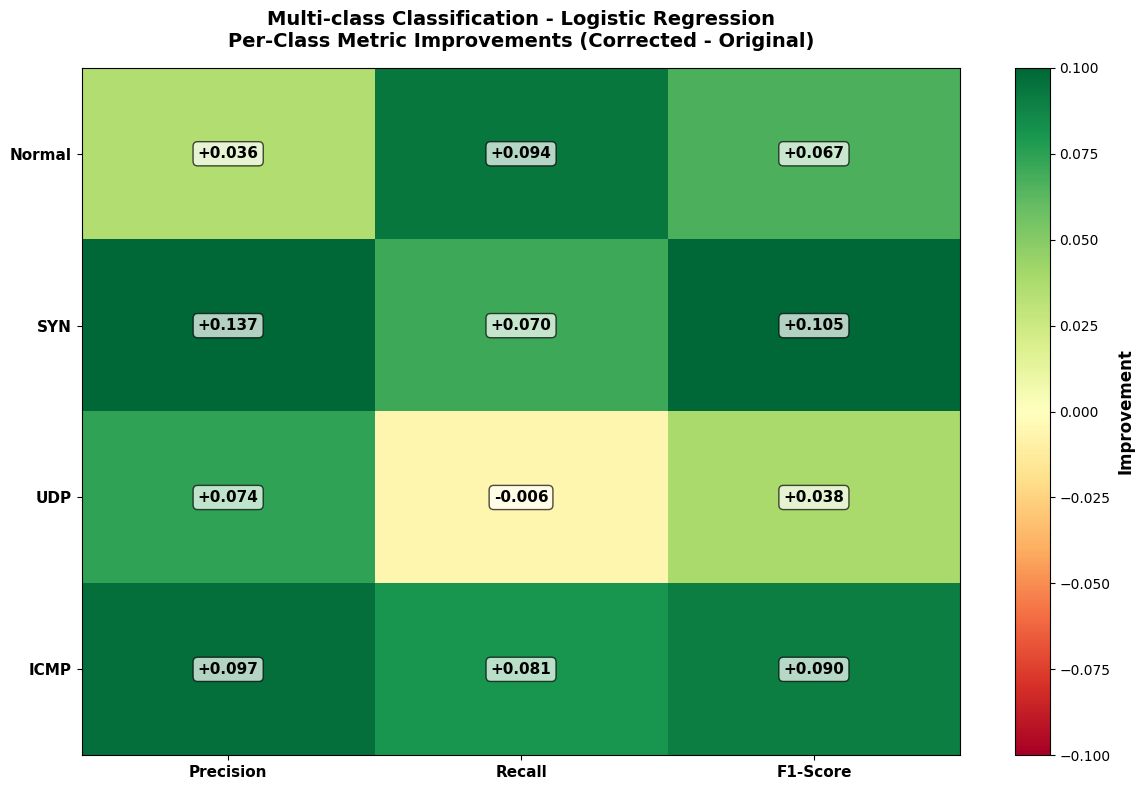

In [86]:
# Summary visualization: Heatmap of improvements with significance
fig, ax = plt.subplots(figsize=(12, 8))

# Create improvement matrix
metrics_names = ['Precision', 'Recall', 'F1-Score']
improvement_matrix = np.zeros((n_classes, len(metrics_names)))

for i in range(n_classes):
    improvement_matrix[i, 0] = (per_class_metrics_corr['precision']['mean'][i] - 
                                per_class_metrics_orig['precision']['mean'][i])
    improvement_matrix[i, 1] = (per_class_metrics_corr['recall']['mean'][i] - 
                                per_class_metrics_orig['recall']['mean'][i])
    improvement_matrix[i, 2] = (per_class_f1_corr['mean'][i] - 
                                per_class_f1_orig['mean'][i])

# Create heatmap
im = ax.imshow(improvement_matrix, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Improvement', fontsize=12, fontweight='bold')

# Set ticks
ax.set_xticks(np.arange(len(metrics_names)))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(metrics_names, fontsize=11, fontweight='bold')
ax.set_yticklabels(class_names, fontsize=11, fontweight='bold')

# Add text annotations
for i in range(n_classes):
    for j in range(len(metrics_names)):
        text = ax.text(j, i, f'{improvement_matrix[i, j]:+.3f}',
                      ha="center", va="center", color="black",
                      fontsize=11, fontweight='bold',
                      bbox=dict(boxstyle='round', facecolor='white', 
                               edgecolor='black', alpha=0.7))

ax.set_title('Multi-class Classification - Logistic Regression\nPer-Class Metric Improvements (Corrected - Original)',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('logistic_regression_results/multiclass_improvement_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [87]:
# Final Summary Table for Multi-class
print("="*120)
print("MULTI-CLASS CLASSIFICATION: COMPREHENSIVE SUMMARY WITH 95% CONFIDENCE INTERVALS")
print("="*120)

summary_multiclass = []

for class_idx, class_name in enumerate(class_names):
    summary_multiclass.append({
        'Class': class_name,
        'Metric': 'Precision',
        'Original': f"{per_class_metrics_orig['precision']['mean'][class_idx]:.3f} "
                   f"[{per_class_metrics_orig['precision']['lower'][class_idx]:.3f}, "
                   f"{per_class_metrics_orig['precision']['upper'][class_idx]:.3f}]",
        'Corrected': f"{per_class_metrics_corr['precision']['mean'][class_idx]:.3f} "
                    f"[{per_class_metrics_corr['precision']['lower'][class_idx]:.3f}, "
                    f"{per_class_metrics_corr['precision']['upper'][class_idx]:.3f}]",
        'Improvement': f"{per_class_metrics_corr['precision']['mean'][class_idx] - per_class_metrics_orig['precision']['mean'][class_idx]:+.3f}"
    })
    
    summary_multiclass.append({
        'Class': '',
        'Metric': 'Recall',
        'Original': f"{per_class_metrics_orig['recall']['mean'][class_idx]:.3f} "
                   f"[{per_class_metrics_orig['recall']['lower'][class_idx]:.3f}, "
                   f"{per_class_metrics_orig['recall']['upper'][class_idx]:.3f}]",
        'Corrected': f"{per_class_metrics_corr['recall']['mean'][class_idx]:.3f} "
                    f"[{per_class_metrics_corr['recall']['lower'][class_idx]:.3f}, "
                    f"{per_class_metrics_corr['recall']['upper'][class_idx]:.3f}]",
        'Improvement': f"{per_class_metrics_corr['recall']['mean'][class_idx] - per_class_metrics_orig['recall']['mean'][class_idx]:+.3f}"
    })
    
    summary_multiclass.append({
        'Class': '',
        'Metric': 'F1-Score',
        'Original': f"{per_class_f1_orig['mean'][class_idx]:.3f} "
                   f"[{per_class_f1_orig['lower'][class_idx]:.3f}, "
                   f"{per_class_f1_orig['upper'][class_idx]:.3f}]",
        'Corrected': f"{per_class_f1_corr['mean'][class_idx]:.3f} "
                    f"[{per_class_f1_corr['lower'][class_idx]:.3f}, "
                    f"{per_class_f1_corr['upper'][class_idx]:.3f}]",
        'Improvement': f"{per_class_f1_corr['mean'][class_idx] - per_class_f1_orig['mean'][class_idx]:+.3f}"
    })

df_summary_multiclass = pd.DataFrame(summary_multiclass)
print(df_summary_multiclass.to_string(index=False))

# Overall Accuracy
print("\n" + "="*120)
print(f"OVERALL ACCURACY:")
print(f"  Original:  {acc_orig_mean:.4f} [95% CI: {acc_orig_lower:.4f}, {acc_orig_upper:.4f}]")
print(f"  Corrected: {acc_corr_mean:.4f} [95% CI: {acc_corr_lower:.4f}, {acc_corr_upper:.4f}]")
print(f"  Improvement: {diff_multi:+.4f} (p-value: {p_val_multi:.4f}) {'***' if sig_multi else 'n.s.'}")
print("="*120)

MULTI-CLASS CLASSIFICATION: COMPREHENSIVE SUMMARY WITH 95% CONFIDENCE INTERVALS
 Class    Metric             Original            Corrected Improvement
Normal Precision 0.937 [0.907, 0.962] 0.972 [0.954, 0.989]      +0.036
          Recall 0.830 [0.789, 0.869] 0.923 [0.894, 0.953]      +0.094
        F1-Score 0.881 [0.854, 0.906] 0.948 [0.930, 0.966]      +0.067
   SYN Precision 0.724 [0.654, 0.791] 0.861 [0.805, 0.914]      +0.137
          Recall 0.849 [0.793, 0.903] 0.919 [0.875, 0.959]      +0.070
        F1-Score 0.782 [0.721, 0.833] 0.887 [0.847, 0.923]      +0.105
   UDP Precision 0.852 [0.794, 0.913] 0.926 [0.878, 0.968]      +0.074
          Recall 0.967 [0.930, 0.993] 0.961 [0.925, 0.987]      -0.006
        F1-Score 0.905 [0.868, 0.938] 0.944 [0.914, 0.969]      +0.038
  ICMP Precision 0.799 [0.705, 0.889] 0.896 [0.826, 0.957]      +0.097
          Recall 0.827 [0.735, 0.914] 0.908 [0.843, 0.971]      +0.081
        F1-Score 0.814 [0.746, 0.878] 0.904 [0.857, 0.952]      +0.0